# Notebook 2 - Join + Analise de Mix + Graficos

Objetivo:
- Ler dados estruturados do PostgreSQL.
- Fazer join entre `fato_movimentacoes` e `dim_produtos_servicos`.
- Calcular m?tricas de mix de produtos.

> Atualizado em 2026-05-13 00:51 apos carga de movimentacoes_202605.json.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from etl_core import obter_engine

plt.style.use('ggplot')
engine = obter_engine()


In [2]:
query = '''
SELECT
    f.data_emissao,
    f.id_produto_servico,
    COALESCE(d.descricao, 'SEM_DESCRICAO') AS descricao_produto,
    COALESCE(d.tipo_item_descricao, 'SEM_CATEGORIA') AS categoria,
    COALESCE(f.qtd_venda, 0) AS qtd_venda,
    COALESCE(f.valor_total_liquido, 0) AS valor_total_liquido,
    COALESCE(f.status_item_cancelado, FALSE) AS status_item_cancelado
FROM silver.fato_movimentacoes f
LEFT JOIN silver.dim_produtos_servicos d
    ON d.id_produto_servico = f.id_produto_servico
'''

df = pd.read_sql_query(text(query), engine)
df.head()


,data_emissao,id_produto_servico,descricao_produto,categoria,qtd_venda,valor_total_liquido,status_item_cancelado
0,2026-05-06,684b14484211dc1ff0823032,Espumante Cave Amadeu Brut Rosé,Bebidas Alcoolicas,30.000,1830.9000,False
1,2026-05-06,62d0d8300345e118a46125bc,Denver Steak Boisul,Carnes Bovinas,7.798,740.8100,False
2,2026-05-06,61230f300345e118a461192c,Entranha Fina Boisul,Carnes Bovinas,5.101,306.0600,False
3,2026-05-06,645b08b00345e118a4611cad,Bife de Chorizo BoiSul,Carnes Bovinas,7.520,503.8400,False
4,2026-05-06,64d5a4300345e118a46128fd,Maminha Fazenda Cristal,Carnes Bovinas,6.035,464.0915,False


In [3]:
df_valid = df[df['status_item_cancelado'] == False].copy()

mix_categoria = (
    df_valid.groupby('categoria', as_index=False)
    .agg(qtd_total=('qtd_venda', 'sum'), faturamento=('valor_total_liquido', 'sum'))
    .sort_values('faturamento', ascending=False)
)

mix_categoria['participacao_faturamento_pct'] = 100 * mix_categoria['faturamento'] / mix_categoria['faturamento'].sum()
mix_categoria.head(15)


,categoria,qtd_total,faturamento,participacao_faturamento_pct
3,Carnes Bovinas,3934.1920,328460.2431,52.187974
6,Carnes e Pereciveis,1784.6078,80146.1874,12.734166
9,Outros Itens Revenda,777.0000,49890.9900,7.927016
0,Bebidas Alcoolicas,670.0000,45070.0874,7.161039
2,Carnes Aves,797.7960,42685.2944,6.782127
5,Carnes Suinas,817.5690,37686.5221,5.987888
8,Mercearia e Acompanhamentos,970.3420,22602.9154,3.591303
4,Carnes Cordeiro,157.8710,10533.6788,1.673662
10,Utensilios e Insumos,411.0000,9168.2700,1.456716
7,Laticinios,847.4180,1934.8739,0.307426


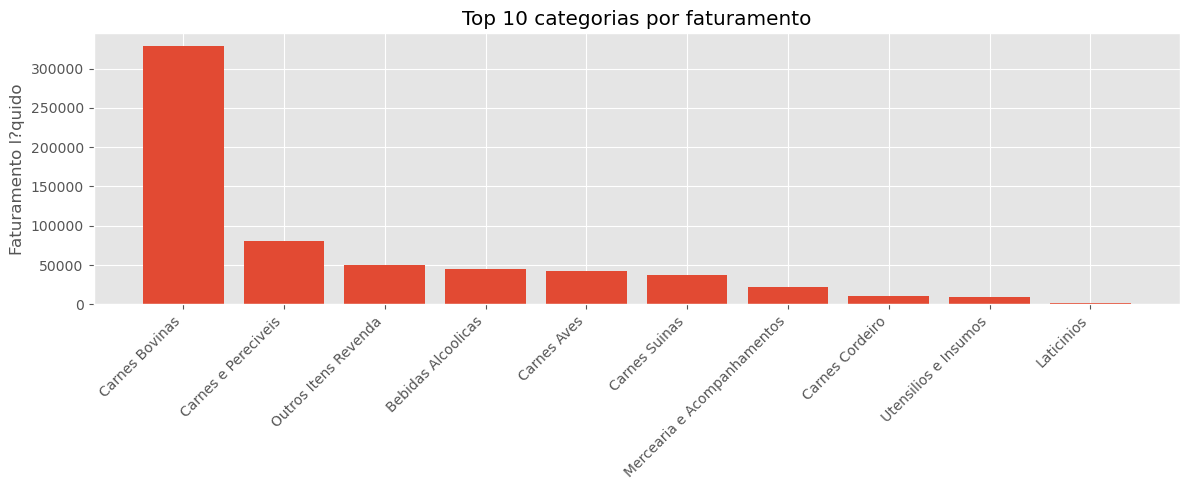

In [4]:
plt.figure(figsize=(12, 5))
plot_df = mix_categoria.head(10)
plt.bar(plot_df['categoria'], plot_df['faturamento'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 categorias por faturamento')
plt.ylabel('Faturamento l?quido')
plt.tight_layout()
plt.show()


In [5]:
mix_produto = (
    df_valid.groupby(['id_produto_servico', 'descricao_produto'], as_index=False)
    .agg(qtd_total=('qtd_venda', 'sum'), faturamento=('valor_total_liquido', 'sum'))
    .sort_values('faturamento', ascending=False)
)

mix_produto['faturamento_acumulado'] = mix_produto['faturamento'].cumsum()
mix_produto['perc_acumulado'] = 100 * mix_produto['faturamento_acumulado'] / mix_produto['faturamento'].sum()
mix_produto['classe_abc'] = np.select(
    [mix_produto['perc_acumulado'] <= 80, mix_produto['perc_acumulado'] <= 95],
    ['A', 'B'],
    default='C'
)

mix_produto.head(30).sort_values('faturamento', ascending=False)


,id_produto_servico,descricao_produto,qtd_total,faturamento,faturamento_acumulado,perc_acumulado,classe_abc
102,6539d6300345e118a461293b,Jantar Parrillero,180.0000,24690.0000,24690.0000,3.922913,A
357,69a2f5714211dc4d14dc0606,Carcaça Frig. Madu,826.5000,24079.4440,48769.4440,7.748817,A
89,64f3f6b00345e118a4611b8a,Picanha Fazenda Cristal,145.0110,20663.9553,69433.3993,11.032046,A
348,698f5ee94211dc233cbbc0e8,Picanha Brasaria,153.0060,17312.3674,86745.7667,13.782751,A
253,6873acdf4211dc53302b8be3,Assado Tiras FS,186.9390,17204.5844,103950.3511,16.516331,A
199,67e456138df90b3394089f54,Entrecot FS,157.1540,15224.9412,119175.2923,18.935372,A
13,5fc854b00345e118a4611bed,Matambre Grill suíno,280.3580,14305.0942,133480.3865,21.208262,A
39,62d0d8300345e118a4611862,Flat Iron Boisul,106.9690,12041.7629,145522.1494,23.121538,A
205,67e45dd38df90b3394089fe4,Costela Dianteiro Black Label,180.0440,11973.1946,157495.3440,25.023920,A
118,662875b00345e118a4611764,Vazio Novilho Jovem,129.8710,11365.1788,168860.5228,26.829696,A


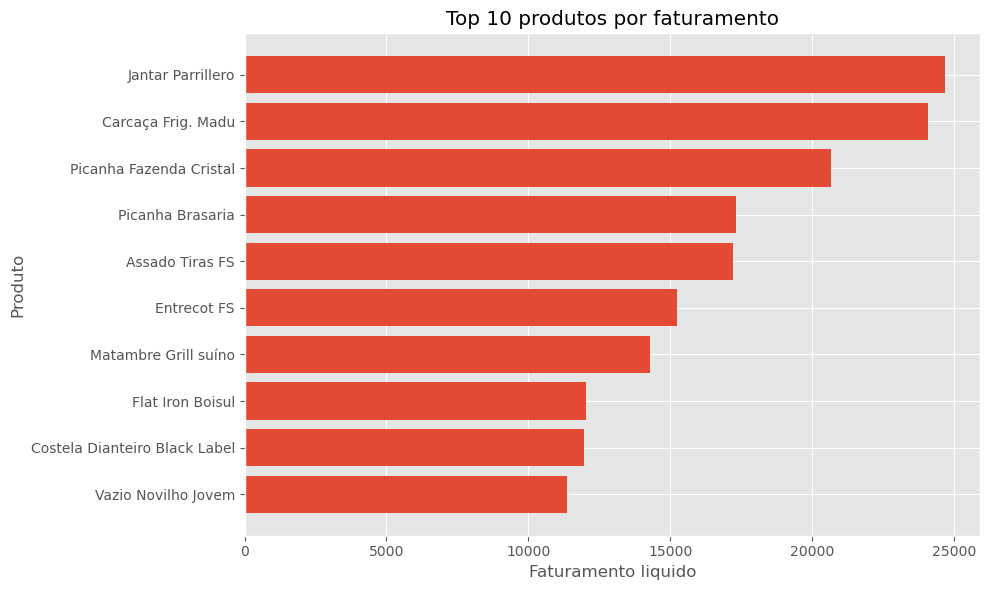

In [6]:
# Top produtos por faturamento
top_prod = mix_produto.head(10).copy()
top_prod = top_prod.sort_values('faturamento', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_prod['descricao_produto'], top_prod['faturamento'])
plt.title('Top 10 produtos por faturamento')
plt.xlabel('Faturamento liquido')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()


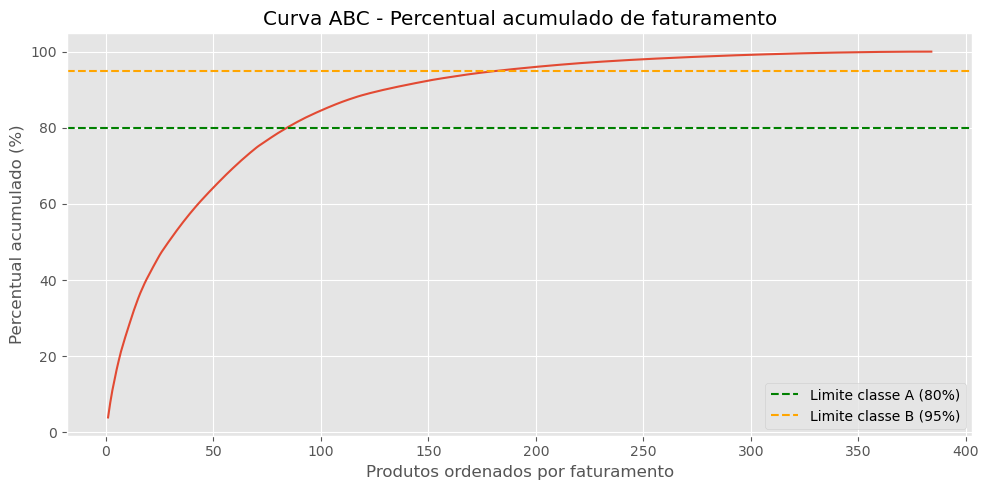

,qtd_produtos
classe,
C,202
B,98
A,84


In [7]:
# Curva ABC: concentracao do faturamento no mix
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(mix_produto) + 1), mix_produto['perc_acumulado'])
plt.axhline(80, color='green', linestyle='--', label='Limite classe A (80%)')
plt.axhline(95, color='orange', linestyle='--', label='Limite classe B (95%)')
plt.title('Curva ABC - Percentual acumulado de faturamento')
plt.xlabel('Produtos ordenados por faturamento')
plt.ylabel('Percentual acumulado (%)')
plt.legend()
plt.tight_layout()
plt.show()

mix_produto['classe_abc'].value_counts().rename_axis('classe').to_frame('qtd_produtos')


In [8]:
# Percentuais da Curva ABC (faturamento e acumulado)
abc_resumo = (
    mix_produto.groupby('classe_abc', as_index=False)
    .agg(
        qtd_produtos=('id_produto_servico', 'count'),
        faturamento_classe=('faturamento', 'sum'),
        perc_acumulado_final=('perc_acumulado', 'max')
    )
    .sort_values('classe_abc')
)
abc_resumo['perc_faturamento_classe'] = 100 * abc_resumo['faturamento_classe'] / abc_resumo['faturamento_classe'].sum()
abc_resumo[['classe_abc','qtd_produtos','faturamento_classe','perc_faturamento_classe','perc_acumulado_final']].round(2)


,classe_abc,qtd_produtos,faturamento_classe,perc_faturamento_classe,perc_acumulado_final
0,A,84,503159.01,79.95,79.95
1,B,98,94492.51,15.01,94.96
2,C,202,31727.67,5.04,100.00


## Resumo atualizado da analise

- Snapshot: `2026-05-13`
- Periodo analisado: `2026-01-05` a `2026-05-12`
- Registros validos (sem cancelados): `4947`
- Produtos com faturamento positivo: `384`
- Faturamento total no periodo: `R$ 629.496,61`
- Categoria lider: `Carnes Bovinas` (52.20% do faturamento)
- Segunda categoria: `Carnes e Pereciveis` (12.73% do faturamento)


## Como explicar a concentracao do mix (Curva ABC)

A Curva ABC mostra quanto do faturamento total esta concentrado nos produtos de maior receita.

- Classe A: 84 produtos, 79.95% do faturamento (acumulado ate 79.95%).
- Classe B: 98 produtos, 15.01% do faturamento (acumulado ate 94.96%).
- Classe C: 202 produtos, 5.04% do faturamento (fecha em 100.00%).

No video, destaque que poucos itens (A) concentram quase todo o resultado e merecem prioridade de estoque, preco e promocao.
